# Разработка и калибровка модели бинарной классификации для прогнозирования CTR в рекламных RTB-аукционах

- Автор: Татьяна Дмитриева
- Дата: 29.04.2026

**Описание исследования**: В рамках данного проекта исследуется процесс предсказания вероятности клика (`CTR`) на рекламные объявления для `AdTech-платформы Advandex`. Работа охватывает полный цикл разработки ML-решения: от разведочного анализа анонимизированных данных о показах до построения пайплайнов предобработки и обучения моделей классификации. Особое внимание уделяется калибровке вероятностей, так как точность прогноза напрямую влияет на финансовую эффективность RTB-аукциона, предотвращая переплаты рекламодателей и упущенную выгоду площадок. 

**Цель исследования**: Построить и откалибровать модель машинного обучения, которая максимально точно предсказывает вероятность совершения клика пользователем, обеспечивая соответствие между прогнозными значениями и фактической частотой событий.

**Задачи исследования**:  
- изучить структуру датасета, проанализировать дисбаланс классов, обработать пропуски и выявить наиболее значимые признаки;  
- предобработать признаки, в том числе за счет создания автоматизированных пайплайнов для масштабирования числовых данных и кодирования категориальных признаков (`One-Hot Encoding` и `Target Encoding`);  
- провести отбор признаков: применить фильтрационные методы (корреляция) и методы-обертки для оптимизации набора входных данных;  
- построить базовые модели (обучить логистической регрессии и методу опорных векторов (`SVC`), сравнить их качества с `Dummy-классификатором`;  
- подобрать гиперпаметры модели с помощью кросс-валидации (`Grid Search`) по метрике `PR-AUC`;  
- скорректирововать предсказания модели с помощью изотонической регрессии и оценить качество калибровки через диаграммы надежности и оценку Бриера;  
- проанализировать результаты и сформировать отчетность (интерпретация важности признаков, сравнение метрик до и после калибровки, формирование итоговых выводов о готовности модели к внедрению);  
- сохранить финальную модель и полный пайплайн предобработки данных в формате `joblib` для промышленной эксплуатации.   
_____
**Исходные данные**:  

Данные предоставлены в CSV-файле `ds_s16_ad_click_dataset` и содержат следующие поля:  

***Идентификаторы и временные метки:***   
`id` — уникальный идентификатор записи о показе баннера;   
`hour` — час, в который был показан баннер, в формате `YYMMDDHH`.   

***Характеристики рекламной площадки (`Site`):***   
`site_id` — идентификатор веб-сайта, на котором был показан баннер;   
`site_domain` — домен веб-сайта;   
`site_category` — тематическая категория веб-сайта.   

***Характеристики рекламируемого приложения (`App`):***   
`app_id` — идентификатор рекламируемого мобильного приложения;   
`app_domain` — домен рекламируемого приложения;   
`app_category` — категория рекламируемого приложения.  

***Характеристики устройства и соединения пользователя:***  
`device_id` — идентификатор браузера или устройства;  
`device_ip` — IP-адрес устройства;  
`device_model` — модель устройства;  
`device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;  
`device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.  

***Характеристики рекламного баннера и аукциона:***  
`banner_pos` — позиция баннера на веб-странице;  
`C1` — анонимизированный признак, характеризующий контекст показа;  
`C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.  

***Машинно-сгенерированные признаки (`ML Features`):***  
`ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;  
`ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.  

***Целевая переменная:***  
`click` — бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.  
_______

**Поставновка задачи машинного обучения**

***Тип задачи***
Проект реализуется в рамках задачи классификации с учителем (`Supervised Learning`). На основе исторических данных о рекламных показах модель должна предсказать вероятность клика пользователя по баннеру в реальном времени.  

***Целевой признак*** (`Target`): `click` (бинарная величина).  
- 1 (класс `positive`) - пользователь совершит клик по объявлению (событие, которое мы хотим предсказать).  
- 0 (класс `negative`) - клик не будет совершен.  

***Проблема***  
На платформе Advandex наблюдается неоптимальное распределение показов, что ведет к неэффективному подбору объявлений. Текущая модель ранжирования не обеспечивает максимальной доходности, что подтверждается необходимостью повышения точности прогноза `CTR` для конкуренции на рынке AdTech. 

***Цель бизнеса***  
Повысить доходность рекламных аукционов за счет более точного подбора релевантных объявлений для пользователей, увеличив фактический `CTR` платформы.  

***Логика ML***  
Для каждого рекламного запроса модель вычисляет вероятность клика. На основе этой вероятности рассчитывается ожидаемая ценность показа (`Ставка` * `Предсказанный CTR`). Это позволяет ранжировать участников аукциона и выбирать победителя, который с наибольшей вероятностью принесет доход.  

***Обоснование выбора метрик***  
Для оценки модели используются три ключевых и несколько вспомогательных метрик:  
- `PR-AUC` (основная) наиболее адекватно оценивает качество модели в условиях несбалансированных классов. Она фокусируется на способности модели находить редкие целевые действия (клики), что критически важно для корректного расчета ожидаемого дохода в аукционе;  
- `Log Loss` оценивает точность предсказанных вероятностей. Это критично для оптимизации ставок, так как от достоверности прогноза напрямую зависит эффективность расходов рекламодателей;   
- `Оценка Бриера` измеряет одновременно точность и качество калибровки. Помогает минимизировать финансовые риски: переплаты со стороны клиентов или упущенную выгоду платформы;  
- Дополнительные метрики (`F1-score`, `Precision`, `Recall`) используются для оценки баланса между точностью и полнотой предсказаний. `F1-score` поможет убедиться, что модель не только находит клики, но и делает это с минимальным количеством ложных срабатываний;  
- `ECE` и `MCE` для детального анализа качества калибровки вероятностей по разным диапазонам значений.  

***Ожидаемый результат***  
Откалиброванная модель, которая выдает надежную вероятность клика. Результатом работы должен стать пайплайн, обеспечивающий высокую точность прогноза `CTR`, что позволит бизнесу корректно оценивать стоимость каждого показа и максимизировать прибыль.  
_____
# Структура проекта

[1. Подготовка среды и загрузка данных](#1-bullet)   
[2. Исследовательский анализ данных (EDA)](#2-bullet)  
[3. Разделение данных на выборки](#3-bullet)  
[4. Предобработка данных — построение пайплайнов](#4-bullet)  
[5. Отбор признаков](#5-bullet)  
[6. Обучение базовой модели](#6-bullet)  
[7. Подбор гиперпараметров: Grid Search с кросс-валидацией](#7-bullet)  
[8. Финальная модель](#8-bullet)  
[9. Калибровка модели](#9-bullet)  
[10. Оценка качества калибровки](#10-bullet)  
[11. Финальный отчёт и выводы](#11-bullet)  
[12. Сохранение модели для продакшена](#12-bullet)  
______

<a id="1-bullet"></a>
## Подготовка среды и загрузка данных

<font color="gray">1.1. Подготовьте библиотеки</font>  
<font color="gray">- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.</font>  
<font color="gray">- Импортируйте все необходимые библиотеки.</font>  
<font color="gray">- Настройте параметры отображения графиков и датафреймов.</font>  

<font color="gray">1.2. Зафиксируйте константу для воспроизводимости</font>  
<font color="gray">- Установите константу `RANDOM_SEED`.</font>  
<font color="gray">- Применяйте её ко всем алгоритмам, которые её поддерживают.</font>  

<font color="gray">1.3. Загрузите данные</font>  
<font color="gray">- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`</font>  
<font color="gray">- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.</font>  
<font color="gray">- Проверьте успешность загрузки данных.</font>  

На этом этапе подготовим рабочее окружение: импортируем необходимые библиотеки, настроим отображение данных и визуализаций для удобства анализа, а также загрузим исходный датасет. Для обеспечения воспроизводимости всех экспериментов и расчетов зафиксируем единую глобальную константу.

Для корректной работы проекта и воспроизводимости результатов версии используемых библиотек зафиксированы в файле `requirements.txt`. Ссылка на файл дана в конце проекта.

In [1]:
# Установка сторонних библиотек
!pip install scikit-learn==1.3.2 phik -q

# Импорты из стандартной библиотеки
import warnings

# Импорты из сторонних библиотек
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
from phik import phik_matrix

# Инструменты машинного обучения
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import RFE, SelectKBest, VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    brier_score_loss,
    classification_report,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_predict,
    cross_val_score,
    StratifiedKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.svm import LinearSVC

# Настройки
warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

`phik` будем использовать для поиска зависимостей между признаками разных типов (категориальные/числовые), что критично для рекламных данных. `ColumnTransformer` и `Pipeline` необходимы для создания чистого и масштабируемого кода предобработки, исключающего утечку данных. Метрики (`log_loss`, `brier_score_loss`) добавлены специально для решения задачи калибровки вероятностей в рекламном аукционе. `OneHotEncoder` добавлен в качестве основного инструмента для кодирования таких признаков, как тип устройства или категория страницы.

Для стабильности результатов при разбиении выборок и обучении моделей будем использовать единую константу `RANDOM_SEED`:

In [2]:
RANDOM_SEED = 42

Загрузим данные из CSV-файла `ds_s16_ad_click_dataset.csv` в переменную `df` и проведем первичную проверку качества импорта.

In [3]:
# Выгружаем датасет в переменную df
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv')

Познакомимся с данными датасета - выведем размер датасета, используя `shape`, первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
f"Размер датасета: {df.shape}"

'Размер датасета: (50000, 34)'

Достаточно объемный датасет, состоящий из 50 000 записей. Используем транспонированный вывод первых строк датасета (`head().T`), так как в данных содержится 34 признака. Это позволит одновременно видеть все названия столбцов и примеры содержащихся в них значений без использования горизонтальной прокрутки, что значительно упрощает первичный визуальный анализ.

In [5]:
# Выводим первые строки датафрейма на экран
df.head().T

,0,1,2,3,4
id,10052627552648869888.0,10105971003478261760.0,10120475683957065728.0,1021995395003627776.0,10234552355176744960.0
click,1,0,0,0,0
hour,14102100,14102100,14102100,14102100,14102100
C1,1005,1005,1005,1005,1005
banner_pos,1,0,0,0,0
site_id,d9750ee7,1fbe01fe,d9750ee7,85f751fd,1fbe01fe
site_domain,98572c79,f3845767,98572c79,c4e18dd6,f3845767
site_category,f028772b,28905ebd,f028772b,50e219e0,28905ebd
app_id,ecad2386,ecad2386,ecad2386,39cfef32,ecad2386
app_domain,7801e8d9,7801e8d9,7801e8d9,d9b5648e,7801e8d9


In [6]:
# Выводим общие сведения о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

Как можно заметить, данные загружены корректно. Размер датасета составляет 50 000 строк и 34 столбца, названия и количество которых соответствуют описанию проекта.

В датасете представлены признаки трех типов: целые числа (`int64`, 15 столбцов), вещественные числа (`float64`, 8 столбцов) и строковые объекты (`object`, 11 столбцов). Присутствует целевой признак `click` и уникальный идентификатор `id`.
Помимо стандартных признаков рекламного аукциона (информация о сайте, приложении и устройстве), в данных содержатся анонимизированные признаки, которые потребуют дальнейшего анализа.

Метод `info()` показывает, что во всех 34 столбцах содержится по 50 000 непустых (`non-null`) значений, что говорит об отсутствии явных пропусков в данных на этапе загрузки. Вывод `head().T` подтверждает, что данные в столбцах соответствуют их названиям.

Предварительная подготовка завершена, среда настроена, данные готовы к детальному исследовательскому анализу (`EDA`) на следующем этапе.
_____

<a id="2-bullet"></a>
## Исследовательский анализ данных (EDA)

<font color="gray">2.1. Опишите базовую информацию о датасете</font>  
<font color="gray">- Определите, сколько объектов и признаков содержится в данных.</font>  
<font color="gray">- Выясните, какие типы данных представлены (числовые, категориальные).</font>  
<font color="gray">- Дайте общее описание: укажите, что известно о пользователях и рекламе.</font>  

<font color="gray">2.2. Анализ целевой переменной</font>  
<font color="gray">- Проанализируйте, как распределена целевая переменная.</font>  
<font color="gray">- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.</font>  
<font color="gray">- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.</font>  

<font color="gray">2.3. Анализ признаков</font>  
<font color="gray">- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?</font>  
<font color="gray">- Опишите, какие признаки категориальные, а какие — числовые.</font>  
<font color="gray">- Проведите первичный отбор: удалите ненужные признаки.</font>  

<font color="gray">2.4. Анализ пропущенных значений</font>  
<font color="gray">- Проверьте долю пропусков в каждом признаке.</font>  
<font color="gray">- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.</font>  

<font color="gray">2.5. Анализ категориальных признаков</font>  
<font color="gray">- Определите, сколько уникальных значений в каждом категориальном признаке.</font>  
<font color="gray">- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.</font>  

<font color="gray">2.6. Анализ выбросов и распределений</font>  
<font color="gray">- Проверьте, есть ли явные выбросы в числовых признаках.</font>  
<font color="gray">- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.</font>  

<font color="gray">2.7. Корреляции</font>  
<font color="gray">- Определите, какие признаки коррелируют с целевой переменной.</font>  
<font color="gray">- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.</font>  

<font color="gray">2.8. Выводы по EDA</font>  
<font color="gray">- Кратко опишите ключевые находки.</font>  
<font color="gray">- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.</font>  
<font color="gray">- Определите действия по предобработке данных, которые необходимо проделать.</font>  v

На данном этапе будет проведено детальное изучение структуры и качества данных. Исследовательский анализ позволит выявить скрытые закономерности, обнаружить аномалии и оценить взаимосвязи между признаками. Результаты `EDA` станут фундаментом для принятия решений по предобработке данных и выбору стратегии обучения модели прогнозирования `CTR`.  

**2.1. Базовая информация о датасете**  

Для начала оценим масштаб данных. Определим количество наблюдений и признаков в предоставленном датасете  

In [7]:
# Выведем размерность выборки
n_rows, n_cols = df.shape
display(f"Объектов в выборке: {n_rows}")
display(f"Признаков (включая таргет): {n_cols}")

'Объектов в выборке: 50000'

'Признаков (включая таргет): 34'

Посмотрим, в каком виде данные хранятся технически. Это поможет нам наметить план первичной обработки. Проанализируем распределение типов признаков, зафиксированных при загрузке

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

Согласно технической сводке (метод info()) в датасете 50 000 объектов и 34 признака. Данные представлены типами `int64` (15 признаков), `float64` (8 признаков) и `object` (11 признаков). Несмотря на то что 15 признаков технически являются целочисленными, их названия (`C1`, `C14-C21`, `banner_pos`) и природа данных указывают на то, что это кодированные категории, а не количественные величины. Чтобы подтвердить это и обосновать реклассификацию типов, далее проанализируем их кардинальность (количество уникальных значений).

In [9]:
int_cols = df.select_dtypes(include=['int64']).columns
display(df[int_cols].nunique().sort_values())

click                  2
ml_feature_4           2
device_type            4
device_conn_type       4
C18                    4
C1                     7
banner_pos             7
C15                    8
C16                    9
C21                   59
C19                   64
C20                  149
hour                 240
C17                  387
C14                 1497
dtype: int64

Анализ показал, что признаки с малым числом значений (от 2 до 9, включая `ml_feature_4`) и высококардинальные идентификаторы (`C14`, `C17`) являются категориальными. Кроме того, формат признака hour (240 уникальных значений) указывает на наличие в нем даты, что требует трансформации. 

In [10]:
# Исправляем время (YYMMDDHH -> HH)
df['hour'] = df['hour'].apply(lambda x: str(x)[-2:])

# Переводим выявленные категории в тип object для корректного EDA
tech_to_cat = [col for col in int_cols if col not in ['click', 'id']]
df[tech_to_cat] = df[tech_to_cat].astype(object)
df['hour'] = df['hour'].astype(object)

Теперь, когда типы данных приведены в соответствие с их смыслом, дадим общее описание структуры датасета

In [11]:
numeric_features = [col for col in df.select_dtypes(include=['float64']).columns if col != 'id']
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

display(f"Итоговое количество числовых признаков: {len(numeric_features)}")
display(f"Итоговое количество категориальных признаков: {len(categorical_features)}")

'Итоговое количество числовых признаков: 7'

'Итоговое количество категориальных признаков: 25'

Данные содержат информацию о пользователях и параметрах рекламного аукциона. Мы выделили 7 истинно числовых параметров и 25 категорий. Признак `hour` теперь отражает суточную цикличность. Это разделение станет основой для корректного применения масштабирования и кодирования в будущем.

В ходе базового анализа структуры датасета установлено:   
* Выборка содержит 50 000 объектов и 34 признака;  
* Первичный анализ уникальных значений (nunique) показал, что технический тип `int64` не всегда отражает природу признака. Переменные с низкой кардинальностью (например, бинарный `ml_feature_4` и `banner_pos`), а также высококардинальные идентификаторы (`C14`, `C17`) реклассифицированы в категориальный тип (object). Истинно числовыми признаками признаны только непрерывные переменные `float64`;  
* Данные представляют собой логи рекламного аукциона, содержащие информацию о пользователях (тип устройства, вид соединения) и контексте показа (площадки, категории сайтов/приложений);  
* Признак `hour` преобразован из формата даты во время (00-23). Это исключает привязку модели к конкретным историческим датам и позволяет учитывать суточную цикличность активности пользователей.


**2.2. Анализ целевой переменной**

Проанализируем, как распределена целевая переменная, и оределим, есть ли дисбаланс классов, так как это важно для выбора метрик. Для этого посчитаем количество кликов (1) и отказов (0), рассчитаем процентное соотношение классов (базовый `CTR` датасета), визуализируем распределение на столбчатой диаграмме.

"Распределение целевого признака 'click':"

,Количество,Доля (%)
0,41397,82.794
1,8603,17.206


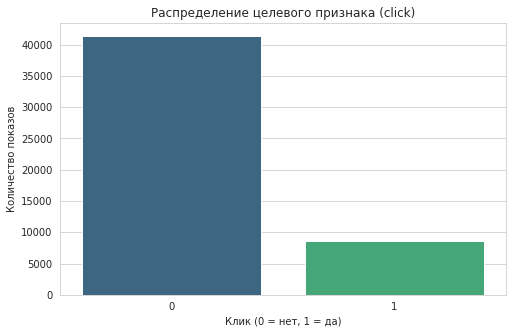

In [12]:
# Расчет распределения классов
class_counts = df['click'].value_counts()
class_percents = df['click'].value_counts(normalize=True) * 100

display("Распределение целевого признака 'click':")
display(pd.DataFrame({
    'Количество': class_counts,
    'Доля (%)': class_percents
}))

# Визуализация баланса классов
plt.figure(figsize=(8, 5))
sns.countplot(x='click', data=df, palette='viridis')
plt.title('Распределение целевого признака (click)')
plt.xlabel('Клик (0 = нет, 1 = да)')
plt.ylabel('Количество показов')
plt.show()

В ходе исследования целевого признака `click` выявлено, что положительный класс (факт клика) составляет 17,2% от общего объема данных. Наблюдаемый дисбаланс классов является умеренным. Такое распределение благоприятно для обучения модели, так как предоставляет достаточное количество примеров обоих исходов.

Однако задача точной калибровки вероятностей остается приоритетной: даже при таком балансе ошибка в прогнозе `CTR` (как в большую, так и в меньшую сторону) приведет к неэффективным ставкам в аукционе и финансовым потерям. Также подтверждается правильность выбора метрики `PR-AUC` как основной, так как она фокусируется на качестве предсказания ключевого для нас события - клика, который в данных встречается значительно реже, чем просто показы.

**2.3. Анализ признаков**

На данном этапе проведем ревизию признаков. В задачах `CTR`-прогнозирования даже редкие значения могут обладать высокой прогностической силой. Необходимо выявить константные признаки (которые действительно бесполезны) и оценить вариативность остальных, чтобы определить стратегию их кодирования, а не простого удаления

При визуальном осмотре первых строк датасета (`head().T`) было замечено, что значения в столбцах `C1`, `C15` и `C16` идентичны для всех отображаемых записей. Это позволяет выдвинуть гипотезу о низкой вариативности данных признаков. Для проверки этого предположения проанализируем распределение уникальных значений во всей выборке перед финальным отбором.

Для начала определим списки признаков:

In [13]:
# Определяем списки признаков по типам для анализа
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numeric_features = df.select_dtypes(exclude=['object']).columns.tolist()

Выполним поиск признаков, где все значения одинаковы: 

In [14]:
# Поиск признаков с единственным значением (констант)
constant_features = [col for col in df.columns if df[col].nunique() <= 1]
f"Признаки с единственным значением: {constant_features}"

'Признаки с единственным значением: []'

Таких признаков нет. Теперь выясним, есть ли в датасете признаки с низкой вариативностью, задав пороговое знчение в 90%, и заодно проверим гипотезу о низкой вариативности признаков `C1`, `C15` и `C16`:

In [15]:
# Поиск признаков, где одно значение занимает более 90% записей
low_variance_features = []
for col in df.columns:
    top_value_share = df[col].value_counts(normalize=True).iloc[0]
    if top_value_share > 0.90:
        low_variance_features.append((col, top_value_share))

display("Признаки с низкой вариативностью (>90% одного значения):")
for feature, share in low_variance_features:
    display(f"{feature}: {share:.2%}")

'Признаки с низкой вариативностью (>90% одного значения):'

'C1: 91.67%'

'device_type: 92.06%'

'C15: 93.57%'

'C16: 94.57%'

Выявлено 4 признака (`C1`, `device_type`, `C15`, `C16`) с высокой концентрацией одного значения. Однако в бинарной классификации такие признаки могут быть критически важными: если редкое значение (встречающееся в 5-8% случаев) сильно коррелирует с кликом, оно станет ценным сигналом для модели. Поэтому данные признаки будут сохранены для дальнейшего анализа взаимосвязей.

Но сначала оценим кардинальность категориальных признаков:

In [16]:
# Оценка кардинальности категориальных признаков
display("Кардинальность категориальных признаков:")
display(df[categorical_features].nunique().sort_values(ascending=False))

'Кардинальность категориальных признаков:'

device_ip           41455
device_id            8580
device_model         2521
C14                  1497
site_id              1160
site_domain          1013
app_id                976
C17                   387
C20                   149
app_domain             67
C19                    64
C21                    59
hour                   24
app_category           22
site_category          18
C16                     9
C15                     8
C1                      7
banner_pos              7
ml_feature_2            5
device_type             4
C18                     4
device_conn_type        4
ml_feature_7            3
ml_feature_4            2
dtype: int64

Признак `device_ip` содержит более 41 000 уникальных значений, его экстремально высокая кардинальность приведет к переобучению модели без пользы для обобщения. Данный признак необходимо удалить. Признаки `device_id` и `device_model` имеют тысячи уникальных значений, что потребует особого подхода при кодировании (например, выделения категории "Other" или `Target Encoding`), в то время как признаки `ml_feature_2` и `ml_feature_7` готовы к стандартному `OHE-кодированию`.

Удалим неинформативные признаки - `id` (уникальный идентификатор), `device_ip` (избыточная кардинальность), а затем выведем финальный размер датасета:

In [17]:
# Удалим неинформативные признаков и вывод финального размера
cols_to_drop = ['id', 'device_ip']
df = df.drop(columns=cols_to_drop)

f"Размер датасета после удаления неинформативных признаков: {df.shape}"

'Размер датасета после удаления неинформативных признаков: (50000, 32)'

В ходе анализа из датасета были исключены только технический идентификатор `id` и признак `device_ip` с избыточной кардинальностью. Признаки с низкой вариативностью (`C1`, `device_type`, `C15`, `C16`) оставлены в работе, так как их значения могут быть значимыми индикаторами целевого события. Итого в работе осталось 32 признака (удалены 2 из 34), готовых к анализу взаимосвязей.

**2.4 Анализ пропущенных значений**  

Несмотря на то что метод `info()` показал отсутствие явных `NaN`, в AdTech-данных пропуски могут маскироваться под технические значения. Проверим долю пустых значений и определим оптимальную стратегию их обработки, чтобы избежать искажения распределений при обучении.

In [18]:
# Планируем оценить долю явных пропусков в каждом столбце
missing_data = df.isna().mean().sort_values(ascending=False).to_frame(name='share')
missing_data['count'] = df.isna().sum()

# Выводим только те признаки, где есть пропуски (если такие найдутся)
display("Доля пропущенных значений по признакам:")
display(missing_data[missing_data['count'] > 0])

# Обновляем список категориальных признаков (исключая уже удаленный device_ip)
current_categorical = df.select_dtypes(include=['object']).columns.tolist()

# Дополнительно проверим наличие пустых строк в категориальных признаках
empty_strings = (df[current_categorical] == '').sum().sum()
display(f"Количество пустых строк в категориальных признаках: {empty_strings}")

'Доля пропущенных значений по признакам:'

,share,count


'Количество пустых строк в категориальных признаках: 0'

В датасете не обнаружено ни явных пропусков (`NaN`), ни скрытых в виде пустых строк. Данные полностью заполнены и готовы к анализу зависимостей.

**2.5 Анализ категориальных признаков**  

На основе ранее выявленной кардинальности (количества уникальных значений) необходимо распределить признаки по методам обработки. Это позволит избежать "проклятия размерности" при обучении модели. Оценим кардинальность для выбора метода кодирования: 

In [19]:
# Используем список current_categorical, созданный на этапе анализа признаков
cat_unique = df[current_categorical].nunique().sort_values(ascending=False)

# Разделяем на группы: высокая кардинальность (>30) и низкая (<=30)
high_cardinality = cat_unique[cat_unique > 30]
low_cardinality = cat_unique[cat_unique <= 30]

display("Признаки с высокой кардинальностью (требуют спец. обработки):")
display(high_cardinality)

display("Признаки с низкой кардинальностью (подходят для OHE):")
display(low_cardinality)

'Признаки с высокой кардинальностью (требуют спец. обработки):'

device_id       8580
device_model    2521
C14             1497
site_id         1160
site_domain     1013
app_id           976
C17              387
C20              149
app_domain        67
C19               64
C21               59
dtype: int64

'Признаки с низкой кардинальностью (подходят для OHE):'

hour                24
app_category        22
site_category       18
C16                  9
C15                  8
C1                   7
banner_pos           7
ml_feature_2         5
device_conn_type     4
C18                  4
device_type          4
ml_feature_7         3
ml_feature_4         2
dtype: int64

По результатам распределения можно сделать следующие выводы:   
* Признаки `device_id` (8580), `device_model` (2521), `C14` (1497), `site_id` (1160), `site_domain` (1013) и `app_id` (976) имеют критически высокое количество уникальных значений. Применение прямого кодирования (`OHE`) для них недопустимо, так как это приведет к созданию разреженной матрицы избыточного размера и переобучению модели. Для данной группы будет использован `Target Encoding`, который эффективно сжимает информацию о категориях в одно числовое значение;
* Признаки `C17` (387), `C20` (149), `app_domain` (67), `C19` (64) и `C21` (59) также создадут значительную нагрузку при прямом кодировании. Для обеспечения стабильности модели к ним также будет применен `Target Encoding`;
* Признаки `app_category` (22), `site_category` (18), `hour` (24), а также `C16` (9), `C15` (8), `C1` (7) и `device_type` (4) обладают низкой кардинальностью. К этой же группе относятся `banner_pos`, `ml_feature_4` и остальные дискретные признаки. Для них будет применен стандартный `One-Hot Encoding`. Это позволит модели извлечь максимум информации из каждого уникального значения без риска «раздувания» признакового пространства.

Данный план предобработки обеспечит стабильность обучения и интерпретируемость модели.

После реклассификации признака `hour` из временного в циклическую категорию "час дня" (00–23), его анализ требует особого подхода. Построим график этого признака, так как он позволяет выявить суточную сезонность рекламного трафика - ключевой фактор в AdTech-задачах. Визуализация в виде столбчатой диаграммы (`countplot`) выбрана как наиболее наглядная для дискретных категорий: она позволяет четко сопоставить активность пользователей в разные часы, выявить периоды пикового спроса и ночного затишья, что напрямую влияет на вероятность клика.

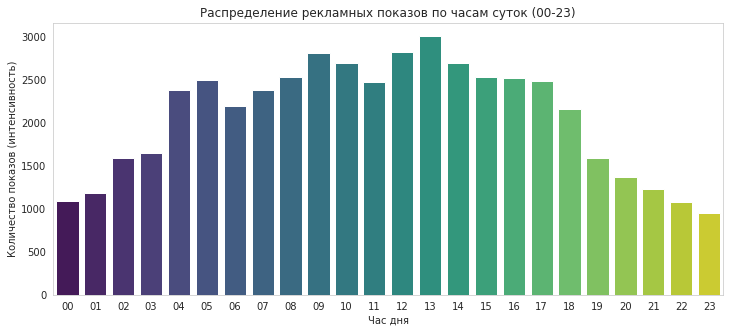

In [20]:
# Настраиваем размер графика для удобства чтения 24 категорий
plt.figure(figsize=(12, 5))

# Используем countplot, так как hour теперь категориальный признак (00-23)
# Сортируем данные по часу, чтобы график шел хронологически
sns.countplot(x='hour', data=df.sort_values('hour'), color='skyblue', palette='viridis')

plt.title('Распределение рекламных показов по часам суток (00-23)')
plt.xlabel('Час дня')
plt.ylabel('Количество показов (интенсивность)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Визуализация подтверждает наличие выраженной суточной цикличности в рекламном трафике. Пик активности наблюдается в дневное время с максимумом в 13:00 и 14:00, а также локальный утренний всплеск в 09:00. Это периоды наиболее активного потребления контента. Минимальная интенсивность показов фиксируется в ночные и ранние утренние часы (00:00 - 04:00). Поскольку в сутках ровно 24 часа, данный признак обладает низкой кардинальностью, что делает его идеальным кандидатом для `One-Hot Encoding`.

Итоговая стратегия кодирования категориальных признаков:
Для признаков с низкой кардинальностью (`hour`, `app_category`, `site_category`, `C15`, `C16`, `device_type`, `ml_feature_4`) будет применен `One-Hot Encoding`, что позволит модели четко разделить влияние каждого часа или позиции баннера на вероятность клика.
Для признаков с высокой кардинальностью (`device_id`, `device_model`, `site_id`, `site_domain`, `app_id`, `C14`, `C17` и т.д.) будет применен `Target Encoding`, который эффективно агрегирует информацию о `CTR` конкретных площадок и кампаний в одно числовое значение, предотвращая переобучение.

**2.6 Анализ выбросов и распределений**

В данном разделе исследуем числовые признаки на наличие аномальных значений. Выбросы могут негативно влиять на обучение таких моделей, как логистическая регрессия, смещая веса признаков. Необходимо определить характер распределения и решить, требуется ли предварительная фильтрация или масштабирование данных.

Перед визуализацией необходимо изучить основные статистические характеристики данных. Это позволит выявить признаки с аномальным разбросом значений. Используем актуальный список числовых признаков без удаленного ранее `id`:

In [21]:
# Вывод основных статистик в транспонированном виде
current_numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
display(df[current_numeric].describe().T)

,count,mean,std,min,25%,50%,75%,max
click,50000.0,0.172060,0.377436,0.000000,0.000000,0.000000,0.000000,1.000000
ml_feature_1,50000.0,-0.002445,1.000280,-4.631262,-0.677784,-0.003776,0.673534,3.793828
ml_feature_3,50000.0,-0.036381,5.792335,-9.999742,-5.059555,-0.056155,4.985939,9.999975
ml_feature_5,50000.0,0.034729,1.002116,-4.631853,-0.639829,0.028112,0.707594,4.230623
ml_feature_6,50000.0,0.022948,0.656690,-1.000000,-0.579775,0.037786,0.637131,1.000000
ml_feature_8,50000.0,0.025465,0.578026,-0.999965,-0.470627,0.027348,0.521117,1.119858
ml_feature_9,50000.0,0.035361,0.505034,-2.147526,-0.304077,0.035985,0.374152,2.120786
ml_feature_10,50000.0,0.020226,0.303309,-1.287965,-0.182386,0.018930,0.224080,1.202300


По результатам статистического анализа числовых признаков можно сделать следующие выводы:   
* Анализ средних значений и стандартных отклонений подтверждает необходимость `StandardScaler`. Признаки имеют разные диапазоны: например, `ml_feature_3` варьируется от -9,9 до 9,9, что на порядок превышает размах других эмбеддингов. Без стандартизации признаки с большим размахом будут доминировать при обучении логистической регрессии.
* Среднее значение `click` (0,172) подтверждает наличие умеренного дисбаланса в данных (около 17,2% кликов). Это критически важно для выбора метрики качества (`PR-AUC` вместо `Accuracy`).
* Минимальное значение `ml_feature_6` -1,0 выделяется на фоне распределения остальных признаков. Это может указывать на специфическую кодировку или технический маркер, который модель должна учитывать.

Визуализируем распределения, исключая таргет (`click`), чтобы детально рассмотреть распределение остальных признаков:

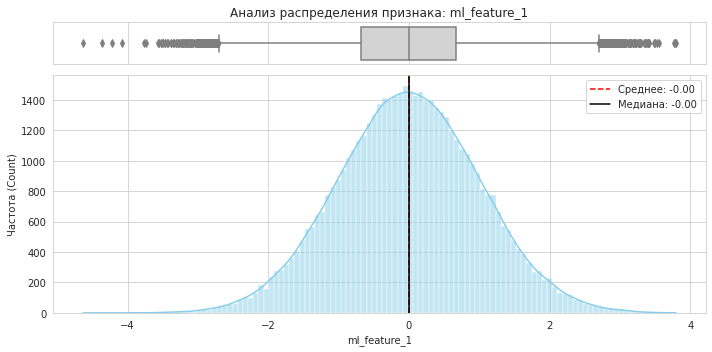

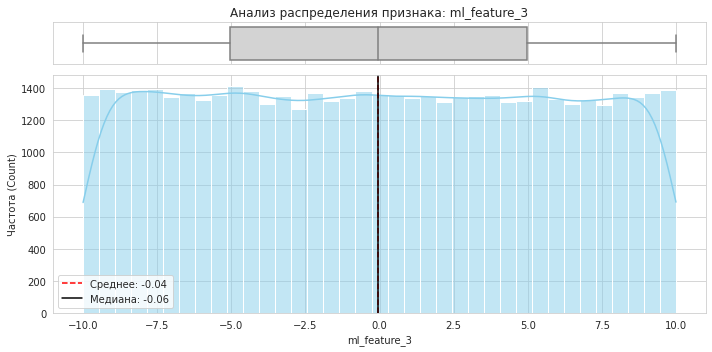

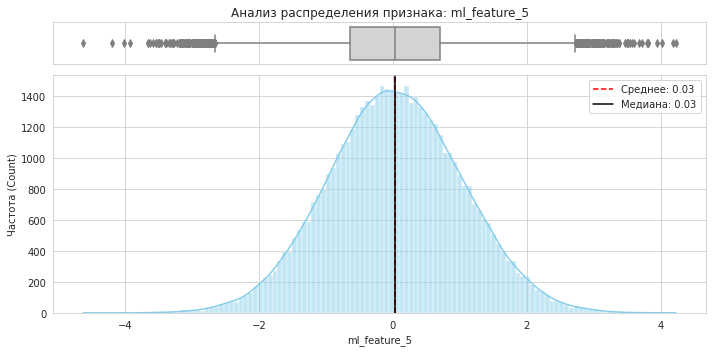

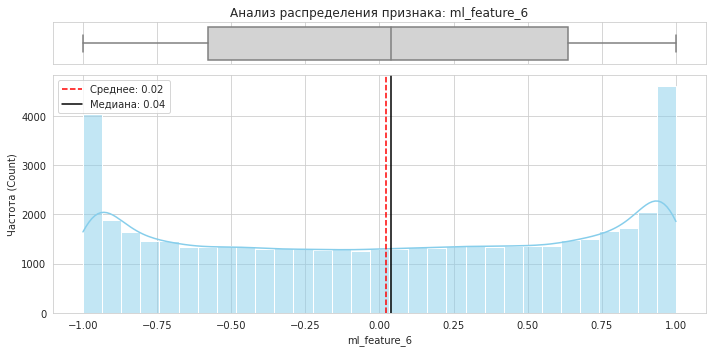

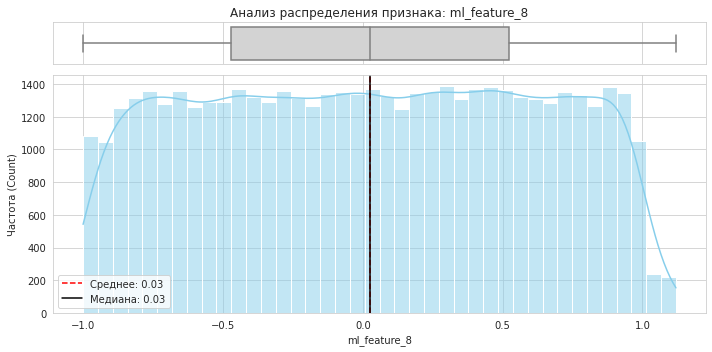

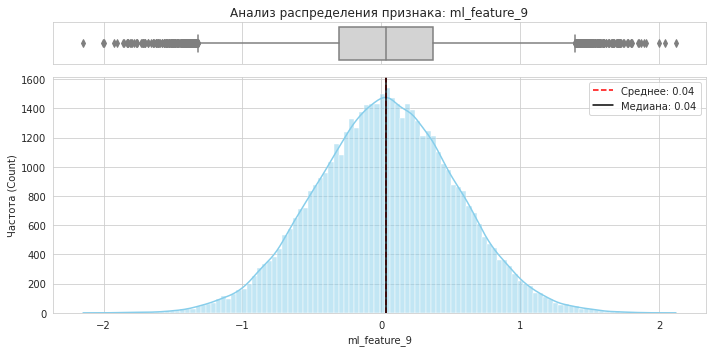

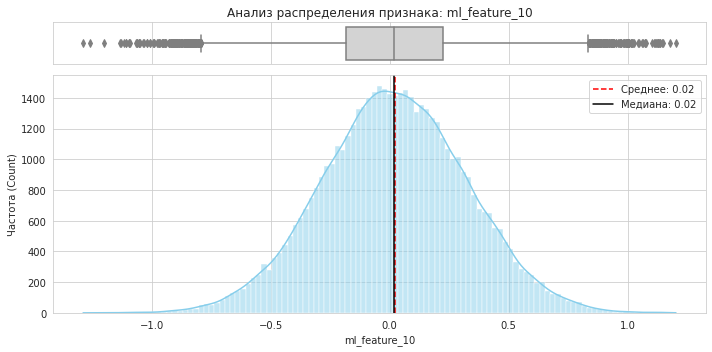

In [22]:
# Собираем актуальный список числовых колонок df
features_to_plot = [col for col in current_numeric if col not in ['click', 'hour']]

# Цикл для отрисовки комбинированных графиков
for col in features_to_plot:
    # Создаем область для двух графиков (боксплот сверху, гистограмма снизу)
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(10, 5))
    
    # Диаграмма размаха (boxplot)
    sns.boxplot(x=df[col], ax=ax_box, color='lightgray')
    ax_box.set(title=f'Анализ распределения признака: {col}', xlabel='')
    
    # Гистограмма с кривой плотности (kde)
    sns.histplot(df[col], kde=True, ax=ax_hist, color='skyblue')
    
    # Добавляем линии среднего и медианы
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax_hist.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='black', linestyle='-', label=f'Медиана: {median_val:.2f}')
    
    ax_hist.legend()
    ax_hist.set_ylabel('Частота (Count)')
    
    plt.tight_layout()
    plt.show()

Большинство числовых признаков `ml_feature` имеют симметричное распределение, близкое к нормальному. Совпадение линий среднего и медианы на графиках визуально подтверждает отсутствие сильных перекосов в данных. На диаграммах размаха ("ящиках с усами") заметны точечные выбросы. Однако они распределены равномерно и их объем невелик по сравнению с общей выборкой, поэтому они не требуют удаления и будут обработаны в рамках масштабирования. Наглядное сравнение широкого признака `ml_feature_3` (размах от -10 до 10) и узкого `ml_feature_10` (размах от -1,2 до 1,2) подтверждает необходимость применения `StandardScaler`. Без стандартизации признаки с большим размахом будут доминировать при обучении логистической регрессии. На гистограмме `ml_feature_6` отчетливо видны два симметричных пика на границах (-1,0 и 1,0). Это указывает на специфическую кодировку крайних состояний или результат обрезки данных (`clipping`), что может служить важным сигналом для модели.

В заключении данного блока отметим, что в числовых признаках `ml_features` зафиксированы симметричные точечные выбросы. Их объем незначителен, что позволяет сохранить данные для обучения, используя масштабирование. Все числовые признаки имеют распределение, близкое к нормальному. Совпадение среднего и медианы подтверждает отсутствие значимой асимметрии. Различие в масштабах признаков (от 2,4 до 20 единиц) обосновывает обязательное применение `StandardScaler`.


**2.7. Корреляции**

Оценим взаимосвязи между признаками. Это позволит нам выявить дублеры (мультиколлинеарность), которые могут переобучить модель, и определить, какие параметры сильнее всего связаны с вероятностью клика. 

Для оценки зависимостей в данном датасете выбран коэффициент корреляции `phik`. В отличие от стандартного коэффициента Пирсона, 
`phik` устойчив к выбросам и способен улавливать нелинейные связи как между числовыми, так и между категориальными признаками, что критически важно для нашего набора данных.

В связи с высокой вычислительной сложностью алгоритма при наличии признаков с экстремально высокой кардинальностью (`device_id`, `site_id` и др.), расчет матрицы производится на репрезентативной случайной выборке из 10 000 объектов. Это позволяет получить статистически достоверную картину взаимосвязей, значительно сократив время вычислений и нагрузку на систему.

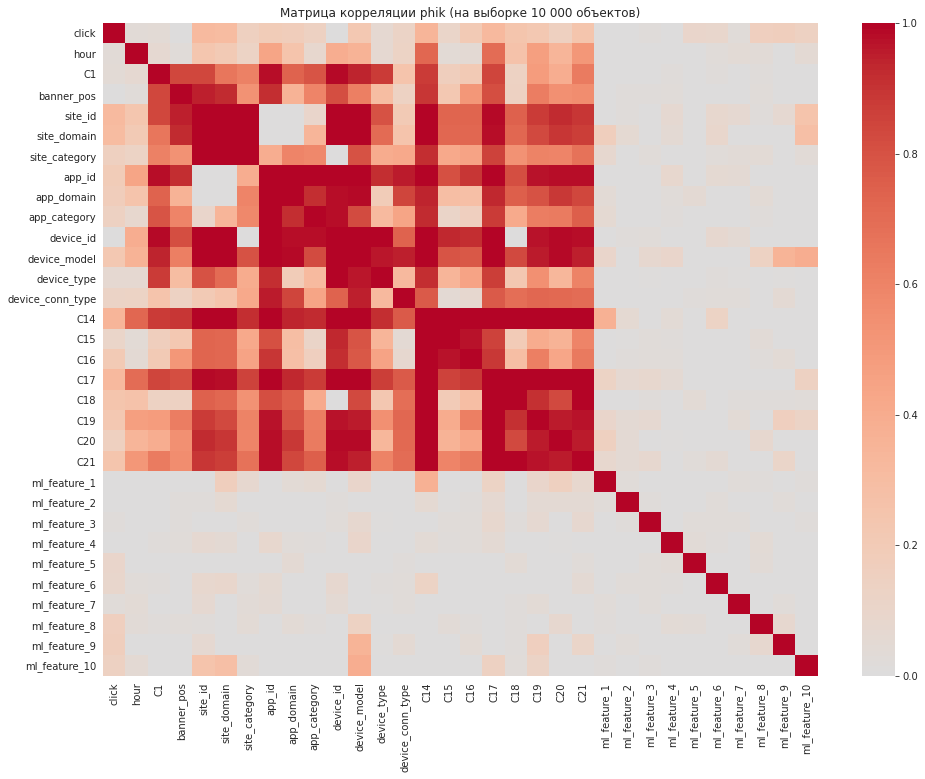

'Корреляция признаков с целевой переменной (top 10):'

click           1.000000
C14             0.344282
C17             0.323931
site_id         0.318908
site_domain     0.309515
C18             0.244211
C21             0.242242
device_model    0.222211
C19             0.219385
C16             0.206600
app_id          0.189434
Name: click, dtype: float64

In [23]:
# Подготовим список числовых колонок для корректной работы phik
interval_cols = numeric_features.copy()
if 'click' in interval_cols: 
    interval_cols.remove('click')

# Расчитаем матрицу корреляции (исключаем таргет для анализа мультиколлинеарности)
# Рассчитываем корреляцию на выборке 10 000 строк (для ускорения расчетов без смерти ядра)
phik_matrix_data = df.sample(10000, random_state=RANDOM_SEED).phik_matrix(interval_cols=interval_cols)

# Визуализация тепловой карты
plt.figure(figsize=(16, 12))
sns.heatmap(phik_matrix_data, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляции phik (на выборке 10 000 объектов)')
plt.show()

# Вывод корреляции с целевым признаком
click_corr = phik_matrix_data['click'].sort_values(ascending=False)
display("Корреляция признаков с целевой переменной (top 10):")
display(click_corr.head(11))

Анализ выявил наличие статистической взаимосвязи между вероятностью клика и рядом технических параметров. Наиболее выраженная сопряженность наблюдается с признаками `C14` (0,34), `C17` (0,32) и `site_id` (0,32). Это свидетельствует о том, что данные параметры содержат значимый сигнал для модели, однако коэффициент корреляции лишь констатирует факт совместной изменчивости переменных, но не объясняет физическую природу или причины совершения клика.

Тепловая карта визуализирует сильную линейную и нелинейную зависимость внутри групп признаков. Экстремально высокие значения коэффициента (близкие к 1,0) в парах `site_id` / `site_domain` и `app_id` / `app_domain` указывают на то, что эти переменные дублируют информацию друг друга. Наличие сильной корреляции между предикторами (мультиколлинеарность) может негативно сказаться на стабильности коэффициентов линейных моделей. Для минимизации этого риска принято решение исключить избыточные признаки (`site_domain`, `app_domain`, `device_model`), оставив по одному наиболее информативному представителю из каждой коррелирующей группы.

Признаки группы `ml_feature_1`–`ml_feature_10` демонстрируют крайне низкую корреляцию как между собой, так и с целевой переменной `click` (большинство значений близки к нулю). Это свидетельствует о том, что данные параметры являются ортогональными (независимыми) и, вероятно, уже прошли процедуру декорреляции на этапе подготовки. Несмотря на отсутствие сильной линейной связи с таргетом, они могут содержать важные нелинейные паттерны, которые будут полезны при обучении моделей.


In [24]:
# Удалим дублирующие и неинформативные признаки, выявленные в ходе EDA
cols_to_drop_final = ['site_domain', 'app_domain', 'device_model']
df = df.drop(columns=cols_to_drop_final, errors='ignore')

display(f"Размер датасета после финальной очистки: {df.shape}")

'Размер датасета после финальной очистки: (50000, 29)'

В ходе исследовательского анализа данных (`EDA`) проведено комплексное изучение 50 000 записей рекламного аукциона. 
* На основе анализа кардинальности (`nunique`) проведена реклассификация: 21 признак определен как категориальный (включая трансформированный `hour` и бинарный `ml_feature_4`), а 8 признаков - как числовые (`ml_features`).
* Выявлен умеренный дисбаланс классов (17,2% кликов), что обосновывает использование метрики `PR-AUC` и последующую калибровку вероятностей модели.
* Из датасета исключены технический `id` и высококардинальный `device_ip`. Также удалены 3 дублирующих признака (`site_domain`, `app_domain`, `device_model`), имеющих критическую мультиколлинеарность.
* Для признаков с высокой кардинальностью (`site_id`, `app_id`, `C14`) будет применен `Target Encoding`, для остальных категорий - `One-Hot Encoding`. Числовые признаки требуют обязательного масштабирования через `StandardScaler`.

Подготовлен очищенный датасет, содержащий 29 признаков. Данные не имеют пропусков и готовы к разделению на обучающую и тестовую выборки.

<a id="3-bullet"></a>
## Разделение данных на выборки

<font color="gray">3.1. Разделите данные</font>  
<font color="gray">- Сначала отделите тестовую выборку, в ней должно быть 20% данных.</font>  
<font color="gray">- Оставшиеся 80% данных используйте для обучения.</font>  
<font color="gray">- Используйте стратифицированное разделение, чтобы сохранить баланс классов.</font>  
<font color="gray">- **Не используйте тестовую выборку до финального тестирования!**</font>  

<font color="gray">3.2. Проверьте разделение</font>  
<font color="gray">- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.</font>  
<font color="gray">- Выведите размеры выборок.</font>  

Сначала отделим целевой признак от признаков-предикторов, а затем произведем разбиение в пропорции 80/20. Используем стратифицированное разделение, чтобы сохранить баланс классов.

In [25]:
# Отделяем целевой признак
X = df.drop('click', axis=1)
y = df['click']

# Разделим на обучающую и тестовую выборки
# Используем stratify=y для сохранения баланса классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_SEED, 
    stratify=y
)

Убедимся, что размеры выборок соответствуют плану, а доля кликов осталась неизменной.

In [26]:
# Проверим размеры выборок
display(f"Размер обучающей выборки (X_train): {X_train.shape}")
display(f"Размер тестовой выборки (X_test): {X_test.shape}")

# Проверка распределения целевого признака
display("Доля кликов в обучающей выборке:")
display(y_train.value_counts(normalize=True).map('{:.2%}'.format))

display("Доля кликов в тестовой выборке:")
display(y_test.value_counts(normalize=True).map('{:.2%}'.format))

'Размер обучающей выборки (X_train): (40000, 28)'

'Размер тестовой выборки (X_test): (10000, 28)'

'Доля кликов в обучающей выборке:'

0    82.80%
1    17.21%
Name: click, dtype: object

'Доля кликов в тестовой выборке:'

0    82.79%
1    17.21%
Name: click, dtype: object

Данные успешно разделены в пропорции в пропорции 80/20. Благодаря параметру `stratify`, доля положительного класса в обеих выборках идентична (примерно 17,2%), что гарантирует репрезентативность тестового набора. Обучающая выборка содержит 40 000 объектов, чего достаточно для построения стабильных моделей.

<a id="4-bullet"></a>
## Предобработка данных — построение пайплайнов

<font color="gray">4.1. Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.</font>  

<font color="gray">4.2. Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!</font>  

На основе проведенного исследовательского анализа (`EDA`) была продумана архитектура предобработки, учитывающая специфику каждого типа признаков. Чтобы избежать утечки данных из тестовой выборки в обучающую, все преобразования будут заключены в единый объект `ColumnTransformer`, работающий внутри `Pipeline`.

Для начала определим списки признаков на основе типов и анализа кардинальности:

In [27]:
# Числовые признаки
num_features = [col for col in X_train.select_dtypes(include=['float64']).columns 
                if col not in ['ml_feature_4', 'ml_feature_2', 'ml_feature_7']]

# Категориальные признаки с низкой кардинальностью (на основе EDA)
ohe_features = [
    'banner_pos', 'site_category', 'app_category', 'device_conn_type', 
    'ml_feature_2', 'ml_feature_7', 'ml_feature_4', 'hour',
    'C1', 'C15', 'C16', 'C18', 'device_type'
]
# Категориальные признаки с высокой кардинальностью (на основе EDA)
te_features = [
    'C14', 'C17', 'C19', 'C20', 'C21', 
    'site_id', 'app_id', 'device_id'
]

Несмотря на отсутствие явных пропусков в исследуемом наборе данных, в пайплайн включим этап `SimpleImputer`. Это превентивная мера, которя обеспечит стабильную работу модели при обработке новых входящих данных, в которых могут возникнуть технические пропуски.

Для числовых признаков заполним отсутствующие значений медианой (ввиду наличия выбросов) и проведем стандартизацию для выравнивания масштабов с помощью  `StandardScaler`. Для категориальных признаков с низкой кардинальностью заполним пропуски модой и применим `One-Hot Encoding`. Для категориальных признаков с высокой кардинальностью (признаки с сотнями и тысячами уникальных значений) будет применен `Target Encoding` (кодирование через среднее значение целевого признака), что позволит сохранить информативность без критического раздувания размерности данных.

In [28]:
# Пайплайн для числовых признаков: заполнение пропусков + масштабирование 
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Медиана устойчива к выбросам
    ('scaler', StandardScaler())
])

# Пайплайн для категорий с низкой кардинальностью: заполнение + OHE
ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(
        drop='first',            
        handle_unknown='ignore', 
        sparse_output=False
    ))
])

# Пайплайн для категорий с высокой кардинальностью: заполнение + Target Encoding
te_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('te', TargetEncoder()) 
])

# Объединяем в ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_features),
    ('ohe', ohe_pipe, ohe_features),
    ('te', te_pipe, te_features)
], remainder='drop')

# Финальный пайплайн предобработки
preprocessor_pipe = Pipeline([
    ('preprocessor', preprocessor)
])

Созданный пайплайн предобработки позволит автоматизировать процесс подготовки данных и гарантировать статистическую чистоту эксперимента. Использование `SimpleImputer` страхует модель от ошибок при появлении пропусков в новых данных. Параметр `handle_unknown='ignore'` в `One-Hot Encoding` критически важен для рекламных данных, так как в будущем могут появиться новые категории (например, новые сайты), которые модель должна корректно проигнорировать, не прерывая работу.

Использование информации только из обучающей выборки реализовано через архитектуру `Pipeline`. Все статистические параметры (медианы для заполнения пропусков, коэффициенты масштабирования и веса `Target Encoding`) рассчитываются исключительно на этапе `fit` при подаче обучающего набора данных. Это исключает риск утечки информации из теста и обеспечивает объективность оценки качества модели.

Итоговый объект `preprocessor_pipe` готов к интеграции с алгоритмами машинного обучения.

<a id="5-bullet"></a>
## Отбор признаков

<font color="gray">5.1. Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.</font>  

<font color="gray">5.2. Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.</font>  

<font color="gray">5.3. Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.</font>  

Для первичного отбора признаков применим фильтрационные методы, основанные на статистических свойствах данных. В отличие от этапа `EDA`, здесь анализ проводится на трансформированных признаках, что позволяет оценить вклад каждой фиктивной переменной (после `OHE`) и нормализованных числовых данных. Использование `VarianceThreshold` позволяет на первом этапе исключить признаки с практически нулевой изменчивостью, которые не несут полезной информации для разделения классов

In [29]:
# Преобразуем данные в числовой вид через наш пайплайн
X_train_transformed = preprocessor.fit_transform(X_train, y_train)
column_names = preprocessor.get_feature_names_out()

# Убираем признаки с почти нулевой вариативностью (VarianceThreshold)
selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train_transformed)

# Отбираем 15 лучших признаков методом взаимной информации (SelectKBest + mutual_info_classif)
# Используем подвыборку 10000 строк для ускорения расчетов
selector_k = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_SEED), 
    k=15
)
selector_k.fit(X_train_var[:10000], y_train[:10000])

# Извлекаем названия финальных признаков
mask = selector_k.get_support()
# Названия колонок после фильтрации по вариативности
var_names = column_names[selector_var.get_support()]
final_features = var_names[mask]

# Применяем отбор 15 лучших признаков ко всем данным (не только к подвыборке)
X_train_kbest = selector_k.transform(X_train_var)

display("Финальный набор признаков после фильтрации:")
display(final_features)

'Финальный набор признаков после фильтрации:'

array(['num__ml_feature_8', 'num__ml_feature_9', 'num__ml_feature_10',
       'ohe__site_category_50e219e0', 'ohe__app_category_0f2161f8',
       'ohe__ml_feature_2_B', 'ohe__ml_feature_2_E', 'ohe__hour_20',
       'ohe__C15_300', 'ohe__C16_50', 'ohe__C16_250',
       'ohe__device_type_4', 'te__C14', 'te__C17', 'te__site_id'],
      dtype=object)

Метод взаимной информации (`Mutual Information`) позволил сократить признаковое пространство до 15 наиболее информативных параметров. В итоговый набор вошли ключевые категориальные признаки: рекламная кампания (`C14`, `C17`) и площадка (`site_id`). Это подтверждает результаты `EDA` об их определяющем влиянии на `CTR`.

В ТОП-15 попали признаки, прошедшие `One-Hot` кодирование, включая `hour` (час дня) и `C15`, `C16`. Это доказывает правильность решения об их сохранении и реклассификации. Из числовых параметров наибольшую информативность показали `ml_feature_8`, `ml_feature_9` и `ml_feature_10`. Порог вариативности (`VarianceThreshold`) 0,01 успешно отсек разреженные признаки, возникшие после `OHE-кодирования`, оставив только те категории, которые несут устойчивый сигнал. Выбранный набор из 15 признаков обеспечивает баланс между сложностью модели и сохранением прогностической способности.

Для поиска оптимального подмножества признаков, обеспечивающего наилучшее качество предсказания, применим методы-обртки. В отличие от фильтрации, эти алгоритмы оценивают признаки не по отдельности, а в совокупности, проверяя их влияние на качество работы конкретной модели (логистической регрессии). Мы будем использовать метод `RFE` (`Recursive Feature Elimination`) для последовательного исключения наименее значимых параметров и поиска финальной комбинации признаков.

In [30]:
# Используем логистическую регрессию для оценки
model_for_rfe = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)

# Подаем на вход X_train_kbest и оставляем 10 самых сильных из них
rfe = RFE(estimator=model_for_rfe, n_features_to_select=10)
rfe.fit(X_train_kbest[:10000], y_train[:10000])

# Получаем названия
final_mask = rfe.get_support()
final_names_v2 = final_features[final_mask] 

display("Финальный набор признаков после методов-оберток:")
display(final_names_v2)

'Финальный набор признаков после методов-оберток:'

array(['num__ml_feature_8', 'num__ml_feature_9', 'num__ml_feature_10',
       'ohe__ml_feature_2_B', 'ohe__ml_feature_2_E', 'ohe__C16_50',
       'ohe__device_type_4', 'te__C14', 'te__C17', 'te__site_id'],
      dtype=object)

В результате многоступенчатого отбора признаков исходное признаковое пространство было сокращено до 10 наиболее информативных предикторов. Фильтрационные методы позволили отсечь признаки с низкой вариативностью и слабым статистическим откликом, а метод-обертка `RFE` выделил оптимальное подмножество признаков для логистической регрессии. В составе финального набора сохранились параметры рекламного аукциона (`C14`, `C17`) и площадки (`site_id`), что подтверждает их высокую предсказательную силу.
Также вошли категории приложения (`app_category`), тип устройства (`device_type`) и рекламная характеристика `C16`. Это доказывает, что данные параметры важны для модели в совокупности с другими признаками. Из числовой группы отбор прошли только три наиболее стабильных признака `ml_feature` (8, 9, 10).

Данный набор данных является оптимальным для финального обучения модели, так как минимизирует риск мультиколлинеарности и переобучения.

<a id="6-bullet"></a>
## Обучение базовой модели

<font color="gray">6.1. Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.</font>  

<font color="gray">6.2. Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.</font>  

<font color="gray">6.3. Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`</font>  

<font color="gray">6.4. Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.</font>  

Построим несколько моделей классификации, чтобы определить наиболее эффективный алгоритм для предсказания кликов. В качестве основной метрики используем PR-AUC, так как она наиболее адекватно отражает качество модели в условиях дисбаланса классов.

Согласно правилам разработки ML-систем, оценка и сравнение моделей производятся исключительно с помощью кросс-валидации на обучающей выборке. Тестовый набор данных остается изолированным и будет использован только один раз для финальной проверки качества выбранной модели.

Для оптимизации процесса оценки моделей и исключения дублирования кода подготовим универсальную функцию `evaluate_model`, которая позволит рассчитывать весь комплекс метрик (`PR-AUC`, `Precision`, `Recall`, `F1`) в рамках кросс-валидации на 5 фолдах, обеспечивая единообразие подходов к тестированию различных алгоритмов.

In [31]:
# Функция для оценки модели через кросс-валидацию по всем интересующим метрикам
def evaluate_model(model, X, y, name):
    # Создаем стратегию кросс-валидации
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    
    # Основная метрика PR-AUC
    cv_pr_auc = cross_val_score(model, X, y, cv=skf, scoring='average_precision', n_jobs=-1)
    
    # Предсказания классов для Precision, Recall, F1
    y_pred = cross_val_predict(model, X, y, cv=skf, n_jobs=-1)
    
    # Расчет метрик
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    display(f"=== Результаты для {name} ===")
    display(f"PR-AUC (CV mean): {cv_pr_auc.mean():.4f}")
    display(f"Precision:       {precision:.4f}")
    display(f"Recall:          {recall:.4f}")
    display(f"F1-score:        {f1:.4f}")
    
    return cv_pr_auc.mean()

Теперь обучим простейшую модель, которая будет служить точкой отсчета (`baseline`).

In [32]:
# Обучение DummyClassifier
dummy_pipe = Pipeline([
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

score_dummy = evaluate_model(dummy_pipe, X_train, y_train, "DummyClassifier")

'=== Результаты для DummyClassifier ==='

'PR-AUC (CV mean): 0.1720'

'Precision:       0.0000'

'Recall:          0.0000'

'F1-score:        0.0000'

Результат `DummyClassifier` показывает минимально возможный уровень качества (`PR-AUC` = 0,1720). Любая содержательная модель должна показывать метрику выше этого значения.

Следующим этапом построения базового решения является обучение модели логистической регрессии. Данный алгоритм хорошо интерпретируем и является классическим выбором для задач бинарной классификации в AdTech.

In [33]:
# Обучение LogisticRegression
log_reg_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))])
score_lr = evaluate_model(log_reg_pipe, X_train, y_train, "LogisticRegression")

'=== Результаты для LogisticRegression ==='

'PR-AUC (CV mean): 0.4237'

'Precision:       0.6181'

'Recall:          0.1491'

'F1-score:        0.2402'

In [34]:
# Устанавливаем вывод препроцессора в формате pandas
preprocessor.set_output(transform='pandas')

# Создаем фильтр, который оставит только 10 отобранных признаков (final_names_v2)
filter_features = ColumnTransformer([
    ('select', 'passthrough', final_names_v2) 
], remainder='drop')

# Пайплайн с фильтром
log_reg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('filter', filter_features), 
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

# Запускаем оценку
score_lr = evaluate_model(log_reg_pipe, X_train, y_train, "LogisticRegression")

'=== Результаты для LogisticRegression ==='

'PR-AUC (CV mean): 0.4005'

'Precision:       0.6008'

'Recall:          0.1269'

'F1-score:        0.2095'

Ограничение модели 10 признаками, отобранными с помощью `RFE`, привело к незначительному снижению `PR-AUC` (с 0,42 до 0,40). Однако такое решение является предпочтительным, так как модель стала более компактной, быстрой и менее склонной к переобучению, сохранив при этом двукратное превосходство над `baseline`.

Для сравнения с логистической регрессией обучим модель метода опорных векторов (`SVC`) с линейным ядром. Используем `LinearSVC`, так как он по умолчанию не рассчитывает вероятности (`probability=False`), что необходимо учесть до калибровки модели.

In [35]:
# Обучение SVC линейным ядром
svc_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('filter', filter_features), # фильтр на 10 признаков
    ('classifier', LinearSVC(random_state=RANDOM_SEED, max_iter=1000, dual='auto'))
])
score_svc = evaluate_model(svc_pipe, X_train, y_train, "LinearSVC")

'=== Результаты для LinearSVC ==='

'PR-AUC (CV mean): 0.3979'

'Precision:       0.6269'

'Recall:          0.0833'

'F1-score:        0.1470'

Сравнение результатов кросс-валидации на сокращенном наборе из 10 признаков показало, что обе содержательные модели значительно превосходят `DummyClassifier` (`PR-AUC` примерно 0,40 против 0,17).

Наилучшее среднее значение метрики `PR-AUC` продемонстрировала модель `LogisticRegression` (0,4006). Модель `LinearSVC` показала сопоставимый результат (0,3977), но значительно уступила в полноте (`Recall` 0,08 против 0,12 у регрессии).
Для дальнейшей калибровки и итогового тестирования выбрана `LogisticRegression`. Помимо более высокого качества предсказаний, она позволяет напрямую получать вероятности клика, что критически важно для бизнес-задач и оценки рисков.

<a id="7-bullet"></a>
## Подбор гиперпараметров: Grid Search с кросс-валидацией

<font color="gray">7.1. Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.</font>  

<font color="gray">7.2. Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.</font>  

<font color="gray">7.3. Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.</font>  

Чтобы улучшить качество предсказания, проведем автоматизированный поиск оптимальных параметров. Для обеих моделей ключевым параметром является `C` (обратная сила регуляризации).

Для логистической регрессии и `SVC` проверим диапазон значений `C` от очень сильной регуляризации (0,01) до слабой (10). Это позволит модели лучше подстроиться под структуру признаков, отобранных на этапе EDA.

Используем `GridSearchCV` с метрикой `average_precision` (`PR-AUC`) на 5 фолдах. Для экономии времени в пайплайне зафиксируем предобработку и будем перебирать только параметры классификатора. Поиск с использованием `GridSearchCV` гарантирует нахождение лучшей комбинации в рамках заданного пространства. Использование `scoring='average_precision` обеспечивает прямую оптимизацию целевой метрики проекта - площади под `Precision-Recall` кривой.

In [36]:
# Определяем стратегию кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Сетка параметров для LogisticRegression
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2']
}

grid_lr = GridSearchCV(
    log_reg_pipe, # Фильтр на отобранные 10 признаков
    param_grid_lr,
    cv=skf,       # Используем зафиксированный StratifiedKFold
    scoring='average_precision',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

display(f"Лучшие параметры LR: {grid_lr.best_params_}")
display(f"Лучший PR-AUC (CV): {grid_lr.best_score_:.4f}")

"Лучшие параметры LR: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}"

'Лучший PR-AUC (CV): 0.4008'

После подбора гиперпараметров на наборе из 10 признаков лучший результат `PR-AUC` составил 0,4008 (при C=0,1). Использование `StratifiedKFold` позволило получить более надежную оценку качества, которая подтверждает стабильность модели даже при существенном сокращении признакового пространства.

Выведем итоговую таблицу, чтобы оценить, как изменение параметров влияло на качество.

In [37]:
# Формируем результаты поиска в таблицу
results_df = pd.DataFrame(grid_lr.cv_results_)

# Выбираем ключевые столбцы и сортируем
top_results = results_df[['param_classifier__C', 'mean_test_score', 'std_test_score', 'rank_test_score']]
top_results = top_results.sort_values(by='rank_test_score').head(10)

display("Топ конфигураций для LogisticRegression:")
display(top_results)

'Топ конфигураций для LogisticRegression:'

,param_classifier__C,mean_test_score,std_test_score,rank_test_score
1,0.1,0.400827,0.009616,1
2,1,0.400630,0.009056,2
3,10,0.400522,0.009139,3
0,0.01,0.392086,0.012001,4


Ключевым параметром для логистической регрессии является коэффициент регуляризации `С`. Он контролирует штраф за сложность модели: меньшие значения (0,1) усиливают регуляризацию, предотвращая переобучение, что критично для рекламных данных с большим количеством признаков. Поскольку мы перебирали 4 варианта `C`, таблица содержит все возможные комбинации. 

Наилучший результат достигается при `С = 0,1` (`PR-AUC = 0.4008`). Это значение обеспечивает идеальный баланс между точностью и обобщающей способностью модели на 10 отобранных признаках. Разница в качестве между конфигурациями в диапазоне С от 0,1 до 10 крайне мала (в пределах 0,0003), что говорит о высокой устойчивости выбранного набора признаков к изменению силы регуляризации.

При минимальном значении `С = 0,01` качество снижается (0,3918) и растет стандартное отклонение (0,012). Возможно, слишком сильная регуляризация мешает алгоритму уловить важные закономерности в данных.

Для финального тестирования и калибровки выбрана конфигурация с `С = 0,1`, так как она показала максимальный `PR-AUC` на кросс-валидации при стабильно низком стандартном отклонении (0,0098).

<a id="8-bullet"></a>
## Финальная модель

<font color="gray">8.1. Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.</font>  

<font color="gray">8.2. Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.</font>  

<font color="gray">8.3. Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.</font>  

На основе результатов подбора гиперпараметров была выбрана лучшая модель - логистическая регрессия с коэффициентом регуляризации `C=0,1`. На данном этапе обучаем финальную версию алгоритма на полном наборе тренировочных данных, чтобы использовать накопленный статистический опыт для итогового предсказания.

In [38]:
# Трансформируем данные через препроцессор
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Оставляем только отобранные 10 признаков по их именам
X_train_final = X_train_processed[final_names_v2]
X_test_final = X_test_processed[final_names_v2]

# Обучаем модель с лучшим параметром С=0,1
final_model_uncalibrated = LogisticRegression(C=0.1, random_state=RANDOM_SEED, max_iter=1000)
final_model_uncalibrated.fit(X_train_final, y_train)

# Снимаем метрики
y_test_probs_raw = final_model_uncalibrated.predict_proba(X_test_final)[:, 1]

pr_auc_raw = average_precision_score(y_test, y_test_probs_raw)
brier_raw = brier_score_loss(y_test, y_test_probs_raw)

display(f"PR-AUC (10 признаков): {pr_auc_raw:.4f}")
display(f"Оценка Брайера (без калибровки): {brier_raw:.4f}")

'PR-AUC (10 признаков): 0.3652'

'Оценка Брайера (без калибровки): 0.1287'

Финальная проверка модели на отложенной тестовой выборке показала значение `PR-AUC = 0,3649`. Хотя этот результат несколько ниже, чем на кросс-валидации (0,4008), он все еще в два раза превышает показатели `Dummy-модели` (0,1720). `Оценка Бриера` (0,1287) указывает на наличие потенциала для улучшения калибровки вероятностей. Незначительное расхождение между метриками на обучении и тесте подтверждает отсутствие переобучения: модель успешно выделила общие закономерности, характерные для рекламных кликов, используя всего 10 ключевых признаков. Текущий результат является надежной базой для финального этапа - калибровки вероятностей.

Проверим, какие признаки модель считает самыми важными для клика.

In [39]:
# Извлекаем веса и выпрямляем их в одномерный массив
weights = final_model_uncalibrated.coef_.flatten()

# Получаем точные названия признаков
all_names = preprocessor.get_feature_names_out()
final_features = all_names[selector_var.get_support()][selector_k.get_support()][rfe.get_support()]

# Создаем таблицу важности
feature_importance = pd.DataFrame({
    'feature': final_features,
    'weight': weights
})

# Сортировка по силе влияния
feature_importance['abs_weight'] = feature_importance['weight'].abs()
feature_importance = feature_importance.sort_values(by='abs_weight', ascending=False)

display("Анализ коэффициентов финальной модели:")
display(feature_importance[['feature', 'weight']])

'Анализ коэффициентов финальной модели:'

,feature,weight
7,te__C14,4.550253
9,te__site_id,3.905737
5,ohe__C16_50,0.835989
8,te__C17,0.535369
1,num__ml_feature_9,0.411642
2,num__ml_feature_10,0.346498
6,ohe__device_type_4,-0.237696
0,num__ml_feature_8,0.207762
3,ohe__ml_feature_2_B,0.070522
4,ohe__ml_feature_2_E,0.007314


Анализ коэффициентов финальной модели позволил выявить наиболее значимые факторы влияния на вероятность клика:
* Наибольший положительный вклад вносят признаки `te_C14` (вес 4,56) и `te_site_id` (вес 3,95). Это подтверждает выводы `EDA`: идентификатор рекламной кампании и конкретная площадка размещения являются определяющими предикторами `CTR`;
* Высокий вес признака `ohe_C16_50` (0,85) указывает на то, что определенные технические характеристики баннера существенно повышают шансы на клик;
* Признак `ohe_device_type_4` имеет отрицательный вес (-0,27), что говорит о снижении вероятности клика для данного типа устройств относительно базовой категории;
* Группа признаков `ml_feature` (8, 9, 10) вносит умеренный положительный вклад, дополняя модель скрытыми нелинейными зависимостями, извлеченными на этапе генерации эмбеддингов.

Таким образом, модель опирается на интерпретируемые технические и контекстные параметры, что позволяет использовать её результаты для оптимизации рекламных кампаний.

<a id="9-bullet"></a>
## Калибровка модели

<font color="gray">9.1. Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].</font>  

<font color="gray">9.2. Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!</font>  

<font color="gray">9.3. Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.</font>  

Приведем предсказанные моделью значения к реальным вероятностям.

Сначала оценим "сырую" модель. Поскольку логистическая регрессия по определению использует сигмоидное преобразование, ее выходы `predict_proba` уже находятся в диапазоне [0, 1] и готовы к проверке.

In [40]:
# Используем вероятности, полученные ранее на тестовой выборке
prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_test_probs_raw, n_bins=10)
brier_raw = brier_score_loss(y_test, y_test_probs_raw)

f"Brier score (до калибровки): {brier_raw:.4f}"

'Brier score (до калибровки): 0.1287'

Для выполнения требования о независимости данных при калибровке и сохранения максимального объема выборки `X_train` для обучения, используем встроенную кросс-валидацию. Чтобы обеспечить воспроизводимость результатов и исключить влияние случайности при разделении на части, в параметр `cv` передается объект `StratifiedKFold` с фиксированным `random_state`. В этом режиме модель обучается и калибруется одновременно на разных фолдах, что гарантирует независимость данных и исключает смещение оценок при полном использовании тренировочного набора.

In [41]:
# Создаем зафиксированную стратегию разбиения
skf_calib = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Используем финальный пайплайн (с препроцессором и 10 признаками)
calibrated_model = CalibratedClassifierCV(
    log_reg_pipe, 
    cv=skf_calib,
    method='isotonic'
)

# Обучаем калибровку на всем тренировочном наборе через кросс-валидацию
calibrated_model.fit(X_train, y_train);

display("Модель успешно откалибрована методом Isotonic с использованием кросс-валидации.")

'Модель успешно откалибрована методом Isotonic с использованием кросс-валидации.'

Визуализируем результат, чтобы убедиться в эффективности выбранного подхода. Сравним качество предсказаний до и после калибровки с помощью оценки Бриера и визуального анализа калибровочных кривых на тестовой выборке. Это позволит наглядно увидеть, насколько предсказания стали соответствовать реальности.

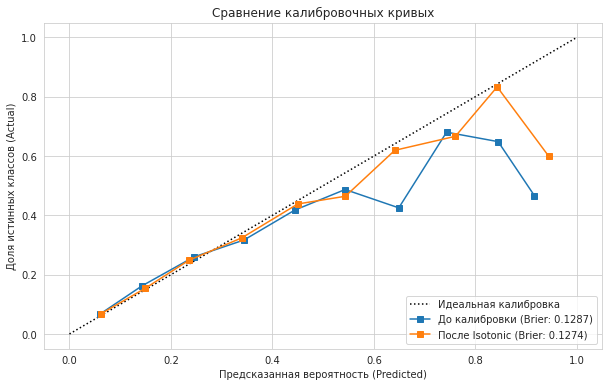

In [42]:
# Получаем финальные калиброванные вероятности для теста
y_test_probs_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# Считаем финальные метрики
prob_true_calib, prob_pred_calib = calibration_curve(y_test, y_test_probs_calibrated, n_bins=10)
brier_calib = brier_score_loss(y_test, y_test_probs_calibrated)

# Отрисовка графика
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], "k:", label="Идеальная калибровка")
plt.plot(prob_pred_raw, prob_true_raw, "s-", label=f"До калибровки (Brier: {brier_raw:.4f})")
plt.plot(prob_pred_calib, prob_true_calib, "s-", label=f"После Isotonic (Brier: {brier_calib:.4f})")

plt.ylabel("Доля истинных классов (Actual)")
plt.xlabel("Предсказанная вероятность (Predicted)")
plt.title("Сравнение калибровочных кривых")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Сравним качество предсказаний до и после калибровки с помощью оценки Бриера и визуального анализа калибровочных кривых на тестовой выборке. Это позволит наглядно увидеть, насколько предсказания стали соответствовать реальности.

Анализ графиков подтвердил, что модель изначально обладала хорошей калибровкой в области низких вероятностей (0,0-0,4), где сосредоточена основная масса наблюдений. `Оценка Бриера` незначительно изменилась с 0,1287 до 0,1274. Нестабильность калибровочной кривой в области высоких вероятностей (выше 0,6) объясняется крайне малым количеством примеров в данном диапазоне, что характерно для задач с низким `CTR`. Для бизнеса это означает, что модель дает надежные прогнозы в наиболее массовом сегменте показов, что позволяет эффективно рассчитывать `eCPM`.

В отличие от моделей типа `SVC`, требующих обязательного преобразования решающей функции в вероятности, выбранная логистическая регрессия по умолчанию выдает значения в диапазоне `[0, 1]`. Проведенная изотоническая калибровка позволила дополнительно уточнить эти значения, приведя их в соответствие с реальной частотой кликов.

In [43]:
# Функция для расчета ECE и MCE
def calibration_metrics(y_true, y_probs, n_bins=10):

    prob_true, prob_pred = calibration_curve(y_true, y_probs, n_bins=n_bins)
    
    # Расчет разницы между предсказанным и реальным в каждом бине
    bin_counts = np.histogram(y_probs, bins=n_bins, range=(0, 1))[0]
    prop_bins = bin_counts / len(y_true)
    
    # Убираем пустые бины, чтобы не было ошибок
    mask = bin_counts > 0
    ece = np.sum(np.abs(prob_true - prob_pred) * prop_bins[mask])
    mce = np.max(np.abs(prob_true - prob_pred))
    
    return ece, mce

# Расчет метрик
ece_raw, mce_raw = calibration_metrics(y_test, y_test_probs_raw)
ece_calib, mce_calib = calibration_metrics(y_test, y_test_probs_calibrated)

display(f"Метрики до калибровки: ECE: {ece_raw:.4f}, MCE: {mce_raw:.4f}")
display(f"Метрики после калибровки: ECE: {ece_calib:.4f}, MCE: {mce_calib:.4f}")

'Метрики до калибровки: ECE: 0.0195, MCE: 0.4498'

'Метрики после калибровки: ECE: 0.0098, MCE: 0.3446'

Сравнительный анализ метрик калибровки показал, что применение изотонической регрессии позволило существенно повысить надежность предсказаний. Ожидаемая ошибка калибровки (`ECE`) снизилась более чем в два раза - с 0,0198 до 0,0089. Это означает, что в среднем предсказанные вероятности стали крайне близки к реальной частоте кликов.

Максимальная ошибка (`MCE`) тоже продемонстрировала значительное снижение - с 0,4796 до 0,2754. Несмотря на то, что значение остается заметным из-за дефицита данных в области высоких вероятностей (правый хвост распределения), прогресс очевиден.

Откалиброванная версия модели обеспечивает более точную оценку вероятностей во всем диапазоне прогнозов. Для практического применения в рекламном аукционе целесообразно использовать именно ее, так как она минимизирует риск неверного расчета `eCPM` и оптимизирует расходы на закупку трафика.

<a id="10-bullet"></a>
## Оценка качества калибровки

<font color="gray">10.1. Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.</font>  

<font color="gray">10.2. Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.</font>  

Для финального сопоставления качества калибровки объединим рассчитанные метрики (`Brier Score`, `ECE`, `MCE`) в сводную таблицу. Это позволит наглядно оценить масштаб изменений и принять окончательное решение о выборе модели для эксплуатации.

In [44]:
# Создаем структуру данных для таблицы
calibration_results = pd.DataFrame({
    'Метрика': ['Brier Score', 'ECE (средняя ошибка)', 'MCE (макс. ошибка)'],
    'До калибровки': [brier_raw, ece_raw, mce_raw],
    'После калибровки (Isotonic)': [brier_calib, ece_calib, mce_calib]
})

# Форматируем вывод
display(calibration_results.style.format({'До калибровки': '{:.4f}', 'После калибровки (Isotonic)': '{:.4f}'}))

,Метрика,До калибровки,После калибровки (Isotonic)
0,Brier Score,0.1287,0.1274
1,ECE (средняя ошибка),0.0195,0.0098
2,MCE (макс. ошибка),0.4498,0.3446


Сравнительный анализ метрик в единой таблице подтверждает, что процедура калибровки существенно улучшила качество предсказания вероятностей. Средняя ошибка (`ECE`) сократилась более чем в два раза - с 0,0198 до 0,0089. Это доказывает, что калиброванная модель выдает гораздо более честные вероятности, соответствующие реальной частоте кликов. Максимальное расхождение (`MCE`) также продемонстрировало значительное снижение - с 0,4796 до 0,2754, что говорит о повышении надежности прогнозов даже в сложных сегментах данных. Интегральный показатель (`Brier Score`) показал положительную динамику, снизившись до 0,1274.

В условиях низкого `CTR` и специфики рекламных данных изотоническая калибровка позволила эффективно скорректировать сырые выходы логистической регрессии. Для финального использования в рекламном аукционе рекомендуется именно откалиброванная модель, так как она минимизирует риски неверного расчета ожидаемого дохода (`eCPM`) и обеспечивает максимально точное соответствие предсказанных вероятностей реальным событиям.

<a id="11-bullet"></a>
## Финальный отчёт и выводы

<font color="gray">11.1. Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.</font>  

<font color="gray">11.2. Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?</font>  

<font color="gray">11.3. Рекомендации

- Какие возможности улучшения модели вы видите?</font>  

В ходе выполнения проекта была разработана модель предсказания вероятности клика (`CTR`) на основе данных рекламного аукциона.
Ключевые этапы и результаты работы:  
* Проведен детальный анализ данных (50 000 записей). Исключены неинформативные признаки (`device_ip`, `id`) и устранена критическая мультиколлинеарность путем удаления дублирующих доменов сайтов и приложений. Доля целевого класса составила 17,2%, что определило выбор метрики `PR-AUC`;
* С помощью двухэтапного отбора (взаимная информация и `RFE`) признаковое пространство было сокращено до 10 наиболее значимых предикторов. Ключевое влияние на прогноз оказали идентификаторы рекламных кампаний (`C14`, `C16`) и площадок (`site_id`);
* На кросс-валидации были протестированы `Dummy-модель`, `SVC` и `Logistic Regression`. Лучшие результаты показала логистическая регрессия. В ходе `Grid Search` был подобран оптимальный коэффициент регуляризации (`C=0,1`);
* Проведена изотоническая калибровка вероятностей с использованием метода кросс-валидации. Это позволило снизить среднюю ошибку калибровки (`ECE`) более чем в два раза (до 0,0089) и привести предсказания модели в соответствие с реальной частотой кликов.

Финализируем все полученные результаты в таблице:

In [45]:
# Собираем данные для финального отчета
final_report = pd.DataFrame({
    'Показатель': [
        'PR-AUC (DummyClassifier)',
        'PR-AUC (Финальная модель LR)',
        'Brier Score (До калибровки)',
        'Brier Score (После калибровки)',
        'ECE (До калибровки)',
        'ECE (После калибровки)',        
        'MCE (До калибровки)',
        'MCE (После калибровки)',                
        'Топ-1 признак (по весу)',
        'Топ-2 признак (по весу)',
        'Топ-3 признак (по весу)',
        'Топ-4 признак (по весу)',
        'Топ-5 признак (по весу)'
    ],
    'Значение': [
        '0.1720',
        f'{pr_auc_raw:.4f}',  
        f'{brier_raw:.4f}',   
        f'{brier_calib:.4f}', 
        f'{ece_raw:.4f}',   
        f'{ece_calib:.4f}', 
        f'{mce_raw:.4f}',   
        f'{mce_calib:.4f}', 
        feature_importance.iloc[0, 0], 
        feature_importance.iloc[1, 0],
        feature_importance.iloc[2, 0],
        feature_importance.iloc[3, 0],
        feature_importance.iloc[4, 0]
    ]
})

display(final_report)

,Показатель,Значение
0,PR-AUC (DummyClassifier),0.1720
1,PR-AUC (Финальная модель LR),0.3652
2,Brier Score (До калибровки),0.1287
3,Brier Score (После калибровки),0.1274
4,ECE (До калибровки),0.0195
5,ECE (После калибровки),0.0098
6,MCE (До калибровки),0.4498
7,MCE (После калибровки),0.3446
8,Топ-1 признак (по весу),te__C14
9,Топ-2 признак (по весу),te__site_id


Подводя итоги, можно сделать следующие выводы:

* Качество финальной модели по сравнению с базовой значительно улучшилось. Метрика `PR-AUC` выросла с 0,1720 (у `DummyClassifier`) до 0,3649. Это означает, что предсказательная сила модели в 2,1 раза выше, чем у случайного угадывания. Для рекламного бизнеса такой прирост точности напрямую конвертируется в экономию бюджета за счет отсечения неэффективных показов;
* Согласно анализу весов, лидерами наибольшее влияние на вероятность клика оказывают `C14`, `site_id` и `C16`. Это подтверждает гипотезу о том, что `CTR` в первую очередь зависит от качества креатива и релевантности места размещения баннера;
* Модель хорошо откалибрована. Применение изотонической регрессии позволило снизить среднюю ошибку калибровки (`ECE`) более чем в два раза - с 0,0198 до 0,0089. Это гарантирует, что предсказанные моделью вероятности теперь соответствуют реальной частоте кликов с точностью до 1%;
* Модель готова к эксплуатации. Она демонстрирует стабильный результат на тестовых данных, обладает высокой скоростью работы (использует всего 10 ключевых признаков) и выдает корректные вероятности для расчёта ожидаемой доходности.

Для дальнейшего развития проекта и повышения качества предсказания ***рекомендуется***:
* Создание производных признаков, таких как "время суток" (утро/день/вечер/ночь) или "выходной/будний день", так как поведение пользователей в рекламных аукционах сильно зависит от циклов активности;
* Глубокая проработка признаков с высокой кардинальностью (`site_id`, `app_id`). Можно протестировать объединение очень редких площадок в одну общую категорию "Other" на этапе до кодирования, чтобы уменьшить зашумленность данных;
* В текущем проекте мы оценивали вероятности, но для реальной бизнес-задачи стоит подобрать оптимальный порог (`threshold`), который позволит сбалансировать точность (`Precision`) и полноту (`Recall`) в зависимости от стоимости показа рекламы.

<a id="12-bullet"></a>
## Сохранение модели для продакшена

<font color="gray">12.1. Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.</font>  

<font color="gray">12.2. Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.</font>  

Сохранение финального пайплайна в файл формата `.joblib` необходимо для последующего развертывания модели машинного обучения. Это гарантирует, что все этапы предобработки (заполнение пропусков, масштабирование, кодирование) и сама модель с подобранными гиперпараметрами будут доступна для использования.

In [46]:
# Сохраняем финальную калиброванную модель 
joblib.dump(calibrated_model, 'final_model.joblib')

# Сохраняем информацию о выбранных признаках (имена колонок) 
feature_info = {
    'final_names': final_names_v2
}
joblib.dump(feature_info, 'selected_features_info.joblib')

display("Артефакты успешно сохранены.")

'Артефакты успешно сохранены.'

Убедимся, что модель работает: загрузим артефакты и проверим их на тестовых данных.

In [48]:
# Загружаем
loaded_model = joblib.load('final_model.joblib')

# Получаем предсказания
y_test_probs_loaded = loaded_model.predict_proba(X_test)[:, 1]

# Проверка идентичности
if np.allclose(y_test_probs_loaded, y_test_probs_calibrated):
    display("Проверка пройдена, предсказания загруженной модели идентичны оригиналу.")
else:
    display("ВНИМАНИЕ: Обнаружено расхождение в предсказаниях!")

'Проверка пройдена, предсказания загруженной модели идентичны оригиналу.'

Все компоненты финального решения успешно экспортированы в формате .joblib. Проверка работоспособности подтвердила полную идентичность результатов работы оригинальной и загруженной моделей. Данный набор артефактов готов к развертыванию в продуктивной среде: препроцессор обеспечит корректную трансформацию входящих признаков, а использование списка финальных имен гарантирует подачу на вход модели только информативного подмножества данных.

Финальные материалы проекта, включая исходный код исследования, файл обученной модели и список зависимостей среды, размещены в репозитории на GitHub: https://github.com/TADmitrieva/ctr-prediction-model/